<div style="margin-bottom: 32px;">
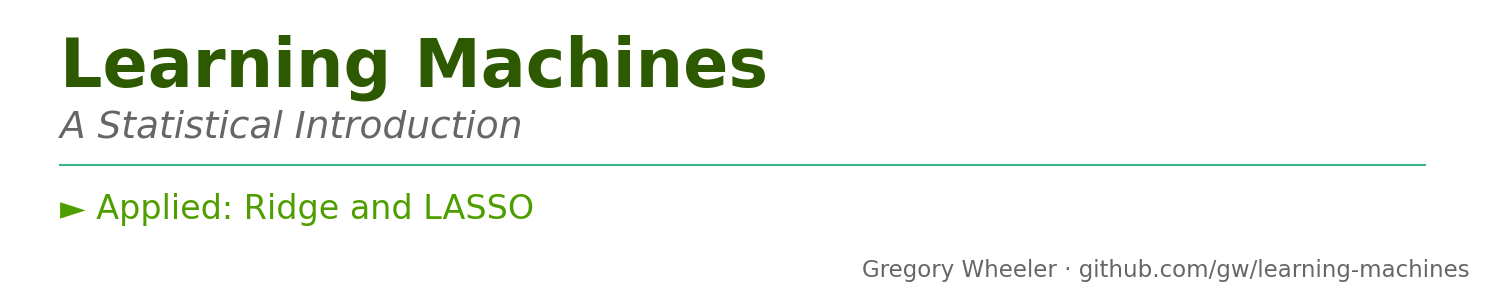
</div>


# Applied — Ridge, LASSO, and the Regularization Path

A short companion to the regularization chapter. On a regression problem where only a handful of features truly matter, we watch ridge and LASSO shrink the coefficients as the penalty grows—and watch LASSO, unlike ridge, drive most of them to *exactly* zero.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mlone_theme as mt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, lasso_path, LassoCV

plt.style.use("mlone_style.mplstyle"); mt.set_notebook_mode()
np.random.seed(0)

## The data: a sparse truth

We make a synthetic regression with 30 features, only **8** of which actually drive the target; the other 22 are noise. Because we know the truth, we can check what each method does with the irrelevant features.

In [2]:
X, y, coef_true = make_regression(n_samples=200, n_features=30, n_informative=8,
                                  noise=10.0, coef=True, random_state=0)
X = StandardScaler().fit_transform(X)
print(f"{X.shape[1]} features; {(coef_true != 0).sum()} of them actually matter")

30 features; 8 of them actually matter


## The regularization path

As the penalty strength grows, both methods pull the coefficients toward zero—but differently. **Ridge** shrinks them smoothly and keeps them all; **LASSO** sends them to *exactly* zero one by one, performing feature selection (Chapter 7).

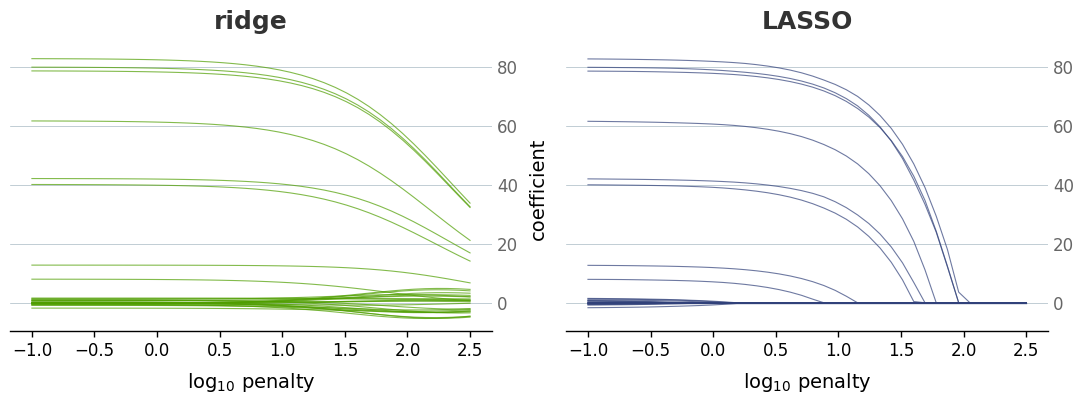

In [3]:
alphas = np.logspace(-1, 2.5, 40)
ridge_coefs = np.array([Ridge(alpha=a).fit(X, y).coef_ for a in alphas])
lasso_alphas, lasso_coefs, _ = lasso_path(X, y, alphas=alphas[::-1])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
a1.plot(np.log10(alphas), ridge_coefs, color=mt.GREEN, lw=0.8, alpha=0.7)
a1.set_title("ridge"); a1.set_xlabel("log$_{10}$ penalty"); a1.set_ylabel("coefficient")
a2.plot(np.log10(lasso_alphas), lasso_coefs.T, color=mt.FS_BLUE, lw=0.8, alpha=0.7)
a2.set_title("LASSO"); a2.set_xlabel("log$_{10}$ penalty")
mt.apply_book_style(a1); mt.apply_book_style(a2)
fig.tight_layout()
plt.show()

## Choosing the penalty, and counting survivors

Cross-validation picks the penalty that predicts best on held-out data. At that choice, LASSO keeps only a fraction of the features nonzero; ridge keeps them all, merely shrunk.

In [4]:
lasso = LassoCV(cv=5, random_state=0).fit(X, y)
print(f"LASSO cross-validated penalty: alpha = {lasso.alpha_:.3f}")
print(f"features kept by LASSO: {(lasso.coef_ != 0).sum()} of {X.shape[1]}")
print(f"features kept by ridge: {X.shape[1]} of {X.shape[1]}  (all shrunk, none exactly zero)")

LASSO cross-validated penalty: alpha = 0.544
features kept by LASSO: 16 of 30
features kept by ridge: 30 of 30  (all shrunk, none exactly zero)


## Try next

- Raise the noise or shrink the sample size; LASSO's selected set becomes less reliable—regularization is trading variance for bias (Chapter 7).
- Compare the features LASSO keeps against the eight that truly matter (`coef_true != 0`): does cross-validation recover them exactly, over-select, or miss some? (At a prediction-optimal penalty it usually over-selects—keeping the true features plus a few spurious ones.)